### [Ultimate Portfolio Diversification](https://medium.com/coding-nexus/ultimate-portfolio-diversification-using-pca-factor-models-cb57c7a58e88)

> Unraveling Asset Returns, Bucketing and Risk Management

In [1]:
!pip install -Uq yfinance statsmodels

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from statsmodels import regression

import warnings
warnings.filterwarnings('ignore')

In [3]:
tickers = ["SPY", "XLE", "XLY", "XLP", "XLI", "XLU", "XLK", "XBI", "XLB", "XLF", "GLD"]

# SPY = S&P 500, XLE = Energy, XLY = Consumer, XLP = Staples
# XLI = Industrials, XLU = Utilities, XLK = Tech, XBI = Biotech
# XLB = Materials, XLF = Finance, GLD = Gold

In [4]:
price_data = yf.download(tickers, period="1y").Close
returns = price_data.pct_change().dropna()
returns = returns.fillna(0)  # handle missing values

[*********************100%***********************]  11 of 11 completed


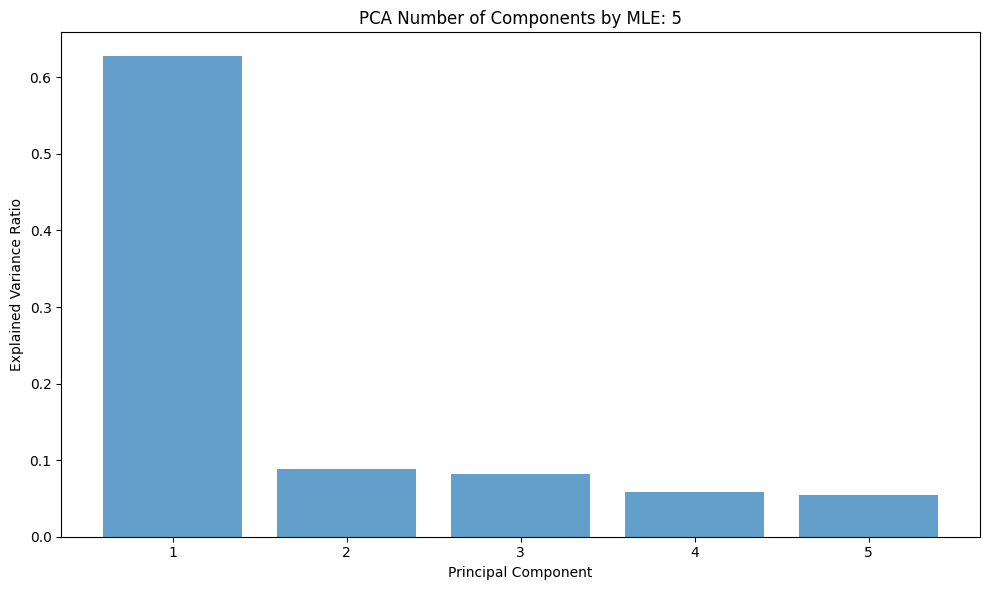

In [5]:
pca = PCA(n_components=0.9, svd_solver="full")
principal_components = pca.fit(returns)
n_components_90 = pca.n_components_
components_90 = pca.components_
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_components_90 + 1), explained_variance, alpha=0.7)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title(f"PCA Number of Components by MLE: {n_components_90}")
plt.tight_layout()
plt.show()

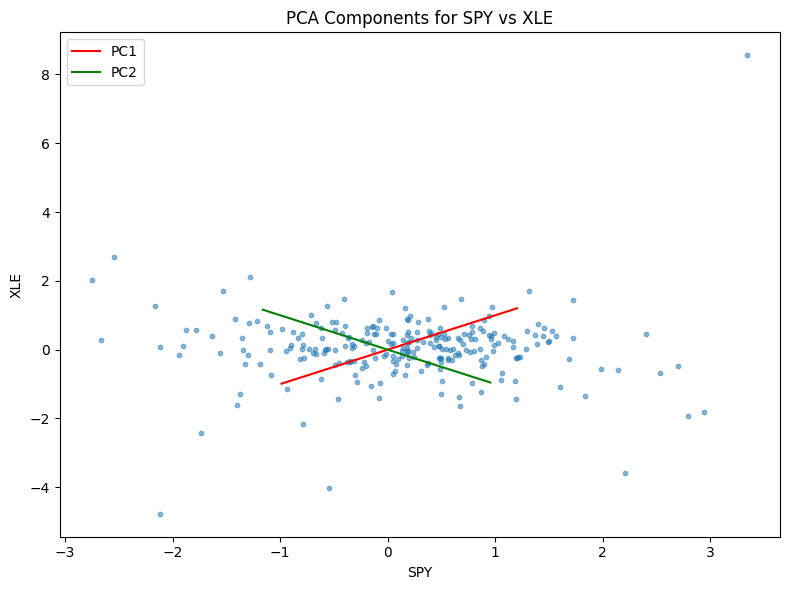

In [6]:
r = returns / returns.std()
r1_s, r2_s = r.iloc[:, 0], r.iloc[:, 1]
pca.fit(np.vstack((r1_s, r2_s)).T)
components_s = pca.components_
evr_s = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))
plt.scatter(r1_s, r2_s, alpha=0.5, s=10)
xs = np.linspace(r1_s.min(), r1_s.max(), 100)
plt.plot(xs * components_s[0, 0] * evr_s[0], xs * components_s[0, 1] * evr_s[0], "r", label="PC1")
plt.plot(xs * components_s[1, 0] * evr_s[1], xs * components_s[1, 1] * evr_s[1], "g", label="PC2")
plt.xlabel(tickers[0])
plt.ylabel(tickers[1])
plt.title(f"PCA Components for {tickers[0]} vs {tickers[1]}")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
factor_returns = np.array(
    [(components_90[i] * returns).T.sum() for i in range(n_components_90)]
)

In [8]:
mlr = regression.linear_model.OLS(
    returns.T.iloc[0], sm.add_constant(factor_returns.T)
).fit()
print(f"Regression coefficients for {tickers[0]}:\n{mlr.params.round(4)}")

Regression coefficients for SPY:
const    0.0002
x1       0.0120
x2      -0.0671
x3       0.5752
x4       0.7261
x5      -0.0267
dtype: float64


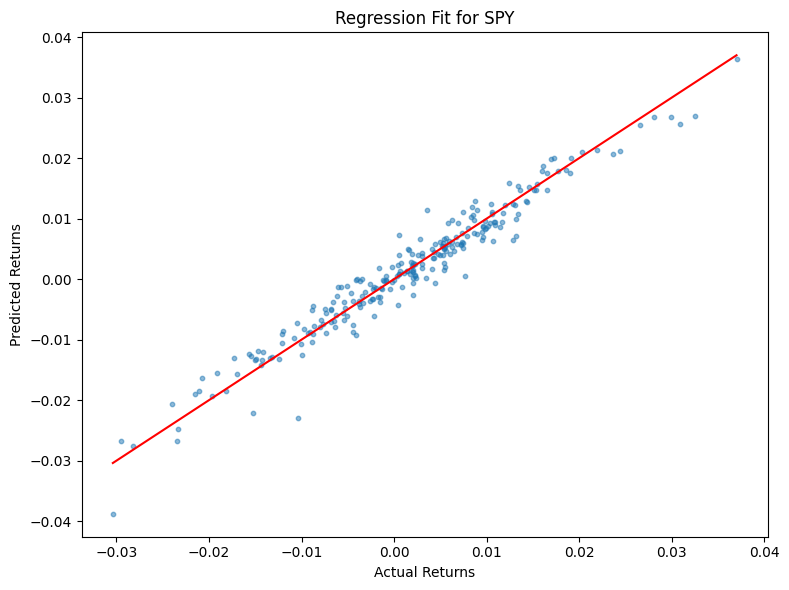

In [9]:
predicted = mlr.predict()
plt.figure(figsize=(8, 6))
plt.scatter(returns.T.iloc[0], predicted, alpha=0.5, s=10)
plt.plot([returns.T.iloc[0].min(), returns.T.iloc[0].max()],
         [returns.T.iloc[0].min(), returns.T.iloc[0].max()], 'r')
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title(f"Regression Fit for {tickers[0]}")
plt.tight_layout()
plt.show()